In [1]:
from typing import List, Optional, Tuple
import warnings
import importlib

import numpy as np
import scipy as sp, pandas as pd, itertools as it
from matplotlib import pyplot as plt
%matplotlib inline
import timeit, time, os, sys, tqdm
from collections import defaultdict

In [2]:
import S_C

In [3]:
import spacecorr
from spacecorr.constants import MERGE_METHODS 

In [10]:
print(spacecorr.__file__)

/home/aa/git/space_corr/src/spacecorr/__init__.py


In [4]:
importlib.reload(S_C)

<module 'S_C' from '/home/aa/git/space_corr/S_C.py'>

In [4]:
df_combined_truncated = pd.read_csv('data/df_combined_truncated.csv')
df_combined_truncated

,cnty,percent_male10,med_age10,percent_black10,percent_white10,total_pop10,pop_density10,log_pop_density10,rep_pre_2008,rep_pre_2012,...,maxtemp0610,mintemp0610,max_heat_index0610,sunlight0610,precipitation0610,Land Area km²,Water Area km²,Total Area km²,Latitude,Longitude
0,1001,48.7,37.0,17.7,78.5,54571,91.8,4.51961,0.257730,72.4941,...,75.45,54.84,1012.0,17728.0,3.67,1539.582,25.776,1565.358,32.536382,-86.644490
1,1003,48.9,41.1,9.4,85.7,182265,114.6,4.74145,0.238119,77.2198,...,76.44,60.06,1042.0,18396.3,4.07,4117.522,1133.19,5250.712,30.659218,-87.746067
2,1005,53.1,39.0,46.9,48.0,27457,31.0,3.43399,0.489854,48.1896,...,76.20,56.13,990.0,17962.5,3.41,2291.819,50.865,2342.684,31.870670,-85.405456
3,1007,53.7,37.8,22.0,75.8,22915,36.8,3.60550,0.265965,72.8266,...,74.93,54.21,1020.0,17509.9,3.85,1612.481,9.289,1621.770,33.015893,-87.127148
4,1009,49.5,39.0,1.3,92.6,57322,88.9,4.48751,0.145135,86.2718,...,72.54,53.16,867.0,16855.1,3.47,1669.962,15.157,1685.119,33.977448,-86.567246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3137,56037,52.2,32.8,1.0,88.5,43806,4.2,1.43508,0.344968,67.6413,...,51.56,34.40,47.0,16846.9,0.57,27004.897,166.887,27171.784,41.660339,-108.875676
3138,56039,52.6,36.9,0.2,88.4,21294,5.3,1.66771,0.606690,42.3761,...,42.95,25.97,13.0,16491.9,2.60,10347.984,572.266,10920.250,44.049321,-110.588102
3139,56041,50.5,33.9,0.3,92.4,21118,10.1,2.31254,0.276393,77.4681,...,49.45,32.20,39.0,17181.1,0.79,5390.450,16.342,5406.791,41.284726,-110.558947
3140,56043,49.9,41.8,0.3,91.4,8533,3.8,1.33500,0.254830,76.4199,...,54.50,38.29,156.0,16242.5,1.08,5797.815,10.762,5808.577,43.878831,-107.669052


In [5]:
df_combined_truncated = df_combined_truncated.replace('-', np.nan)

In [6]:
# for each list of indices present, finds the pairs of variables that overlap on these indices 
row_pattern_to_pairs = defaultdict(list)
columns_truncated = df_combined_truncated.columns
n_cols = len(columns_truncated)

for i in range(n_cols):
    for j in range(i+1, n_cols):
        col1, col2 = columns_truncated[i], columns_truncated[j]
        valid_rows = df_combined_truncated[[col1, col2]].dropna().index.tolist()
        valid_rows_key = tuple(valid_rows)
        row_pattern_to_pairs[valid_rows_key].append((col1, col2))
print(f"found {len(row_pattern_to_pairs)} distinct row patterns\n")

for row_pattern, pairs in sorted(row_pattern_to_pairs.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{len(row_pattern)} {len(pairs)}")

found 178 distinct row patterns

3142 190
3106 155
2056 87
3141 63
3141 41
3137 41
2004 32
2115 29
3091 29
3112 28
2502 27
2591 26
2738 26
3128 25
2828 25
2861 25
2954 25
2953 25
3122 23
2958 23
3113 20
3140 20
2050 15
3140 6
2055 6
3136 6
2109 5
3085 5
3083 5
3088 5
2925 5
2809 5
2837 5
2564 5
2474 5
2924 5
2923 5
2708 5
1999 5
3104 5
3136 4
1376 3
2044 3
3112 3
2054 3
2054 3
1990 3
3139 3
2029 3
2042 3
1875 3
1829 3
2042 3
2042 3
1925 3
1952 3
3127 2
3112 2
3121 2
2957 2
2827 2
2860 2
2590 2
2501 2
2953 2
2952 2
2737 2
3139 2
3108 2
3117 2
2953 2
3135 2
3089 1
3094 1
2931 1
2815 1
2843 1
2570 1
2480 1
2930 1
2929 1
2714 1
3110 1
3102 1
3109 1
2946 1
2825 1
2857 1
2585 1
2495 1
2946 1
2945 1
2730 1
3126 1
2095 1
2100 1
2101 1
2003 1
1946 1
1972 1
1842 1
1783 1
2058 1
2057 1
1931 1
1360 1
2114 1
3068 1
3073 1
2910 1
2794 1
2822 1
2551 1
2462 1
2909 1
2908 1
2693 1
1994 1
3089 1
3099 1
2941 1
2821 1
2852 1
2581 1
2489 1
2935 1
2934 1
2721 1
2003 1
3111 1
2946 1
2826 1
2855 1
2582 1
2493

In [8]:
MERGE_METHODS

['single', 'median', 'average', 'complete']

In [12]:
trace_ALL = {} 
merge_orders_ALL = {} 
for i, (row_pattern, var_pairs) in tqdm.tqdm(enumerate(sorted(row_pattern_to_pairs.items(), key=lambda x: len(x[1]), reverse=True))): 
    # print(f"{len(row_pattern)} {var_pairs}")
    print(f'pattern {i}, {len(var_pairs)} pairs')
    coordinates_variable = df_combined_truncated[['Latitude', 'Longitude ']].iloc[list(row_pattern)]

    trace_ALL[row_pattern] = {} 
    merge_orders_ALL[row_pattern] = {} 
    # merge_orders is one set of all methods for each row_pattern (size 4) 
    # need to end up with all merge orders, and the traces for this merge order 
    merge_orders = {} 
    for merge_method in merge_methods: 
        merge_order = SCC.get_merge_order(np.array(coordinates_variable), method=merge_method) 
        merge_orders_ALL[row_pattern][merge_method] = merge_order 
        trace_ALL[row_pattern][merge_method] = {} 
        for var_pair in var_pairs: 
            var_x = df_combined_truncated[var_pair[0]].iloc[list(row_pattern)].values.astype(float)
            var_y = df_combined_truncated[var_pair[1]].iloc[list(row_pattern)].values.astype(float)
            try:
                trace = SCC.get_space_corr(var_x, var_y, merge_order) 
            except TypeError:
                print(var_pair, var_x, var_y)
            trace_ALL[row_pattern][merge_method][var_pair] = trace 
            
        
    print(np.max(merge_order), len(merge_order)) 

    # for merge_method in tqdm.tqdm(merge_methods):
    #     merge_order = merge_orders[merge_method]
        
    """
    for var_pair in var_pairs: 
        var_pair_key = "--".join(var_pair_key)
        res_ALL[var_pair_key] = {}
            res = compute_scc_matrix_gpu_wrapper(
                values_allrows, 
                merge_order,
                batch_size=150,
                verbose=False)
            res_ALL[merge_method] = res
    """

0it [00:00, ?it/s]

pattern 0, 190 pairs


1it [00:09,  9.09s/it]

3141 3141
pattern 1, 155 pairs


2it [00:16,  8.08s/it]

...

2952 2952
pattern 174, 1 pairs


176it [01:49,  3.45it/s]

2730 2730
pattern 175, 1 pairs
1988 1988
pattern 176, 1 pairs


178it [01:50,  1.61it/s]

2951 2951
pattern 177, 1 pairs
1860 1860


In [18]:
trace_ALL[row_pattern]

{'single': {('percent_fair_or_poor_chr12', 'ls09_10_avg'): [0.0,
   -0.9999999999999998,
   -0.2568679416014547,
   -0.24834452794209402,
   -0.4214138484620644,
   -0.11530731205686416,
   -0.21048566442294878,
   -0.11598589857062704,
   -0.16346775451434337,
   -0.22888769602334139,
   -0.19562258115149878,
   -0.1103065622755188,
   -0.24722362938045023,
   -0.18780054194665732,
   -0.22574651513419677,
   -0.15210984392532764,
   -0.16034227124896755,
   -0.2145983219526568,
   -0.2156047685853566,
   -0.22059504344278635,
   -0.16433878098879168,
   -0.15345184591534475,
   -0.29928214899992417,
   -0.28217222201737274,
   -0.28156213522040474,
   -0.2838292186903783,
   -0.2820253408179096,
   -0.2779902246305195,
   -0.3382445124517919,
   -0.4009965259752589,
   -0.3628831451656722,
   -0.3562451188638415,
   -0.3668586349035445,
   -0.3731183955466319,
   -0.3937305978663243,
   -0.3986972595055415,
   -0.3631441203197756,
   -0.3687536628747382,
   -0.37688638105951916,
   -

In [42]:
trace_ALL_flat = [
    np.transpose(np.stack([
        np.stack([
            np.array(trace)
            for pair, trace in traces.items()
        ])
        for merge_method, traces 
        in sorted(trace_row_pattern.items(), key=lambda x: x[0])
    ]), (1,0,2))
    for row_pattern, trace_row_pattern
    in trace_ALL.items()
]
[arr.shape for arr in trace_ALL_flat]

[(190, 4, 3142),
 (155, 4, 3106),
 (87, 4, 2056),
 (63, 4, 3141),
 (41, 4, 3141),
 (41, 4, 3137),
 (32, 4, 2004),
 (29, 4, 2115),
 (29, 4, 3091),
 (28, 4, 3112),
 (27, 4, 2502),
 (26, 4, 2591),
 (26, 4, 2738),
 (25, 4, 3128),
 (25, 4, 2828),
 (25, 4, 2861),
 (25, 4, 2954),
 (25, 4, 2953),
 (23, 4, 3122),
 (23, 4, 2958),
 (20, 4, 3113),
 (20, 4, 3140),
 (15, 4, 2050),
 (6, 4, 3140),
 (6, 4, 2055),
 (6, 4, 3136),
 (5, 4, 2109),
 (5, 4, 3085),
 (5, 4, 3083),
 (5, 4, 3088),
 (5, 4, 2925),
 (5, 4, 2809),
 (5, 4, 2837),
 (5, 4, 2564),
 (5, 4, 2474),
 (5, 4, 2924),
 (5, 4, 2923),
 (5, 4, 2708),
 (5, 4, 1999),
 (5, 4, 3104),
 (4, 4, 3136),
 (3, 4, 1376),
 (3, 4, 2044),
 (3, 4, 3112),
 (3, 4, 2054),
 (3, 4, 2054),
 (3, 4, 1990),
 (3, 4, 3139),
 (3, 4, 2029),
 (3, 4, 2042),
 (3, 4, 1875),
 (3, 4, 1829),
 (3, 4, 2042),
 (3, 4, 2042),
 (3, 4, 1925),
 (3, 4, 1952),
 (2, 4, 3127),
 (2, 4, 3112),
 (2, 4, 3121),
 (2, 4, 2957),
 (2, 4, 2827),
 (2, 4, 2860),
 (2, 4, 2590),
 (2, 4, 2501),
 (2, 4, 2953),


In [145]:
# finding out the order of the merge methods in the trace_ALL dictionary 
[sorted(list(trace_ALL.items())[-1][1].items(), key=lambda x: x[0])[i][0] for i in [0,1,2,3]]

['average', 'complete', 'median', 'single']

In [76]:
trace_ALL_flat_flat = [item for sublist in trace_ALL_flat for item in sublist]
len(trace_ALL_flat_flat)

1275

In [77]:
trace_ALL_flat_flat[1]

array([[ 0.        , -1.        , -0.96587154, ...,  0.04109059,
         0.05062186,  0.05055132],
       [ 0.        , -1.        , -0.96587154, ...,  0.04109059,
         0.05062186,  0.05055132],
       [ 0.        , -1.        , -0.96587154, ...,  0.04109059,
         0.05062186,  0.05055132],
       [ 0.        , -1.        , -0.96587154, ...,  0.05152171,
         0.05062186,  0.05055132]])

In [73]:
pairName_ALL_flat = [
    [
        pair
        for pair, trace in trace_row_pattern['complete'].items()
    ]
    for row_pattern, trace_row_pattern
    in trace_ALL.items()
]
pairName_ALL_flat = [item for sublist in pairName_ALL_flat for item in sublist]
pairName_ALL_flat

[('cnty', 'percent_male10'),
 ('cnty', 'med_age10'),
 ('cnty', 'percent_black10'),
 ('cnty', 'percent_white10'),
 ('cnty', 'total_pop10'),
 ('cnty', 'high_school0509'),
 ('cnty', 'bac0509'),
 ('cnty', 'grad0509'),
 ('cnty', 'married0509'),
 ('cnty', 'divorced0509'),
 ('cnty', 'separated0509'),
 ('cnty', 'other_language0509'),
 ('cnty', 'foreign_born0509'),
 ('cnty', 'same_sex0509'),
 ('cnty', 'elev'),
 ('cnty', 'Land Area km²'),
 ('cnty', 'Total Area km²'),
 ('cnty', 'Latitude'),
 ('cnty', 'Longitude '),
 ('percent_male10', 'med_age10'),
 ('percent_male10', 'percent_black10'),
 ('percent_male10', 'percent_white10'),
 ('percent_male10', 'total_pop10'),
 ('percent_male10', 'high_school0509'),
 ('percent_male10', 'bac0509'),
 ('percent_male10', 'grad0509'),
 ('percent_male10', 'married0509'),
 ('percent_male10', 'divorced0509'),
 ('percent_male10', 'separated0509'),
 ('percent_male10', 'other_language0509'),
 ('percent_male10', 'foreign_born0509'),
 ('percent_male10', 'same_sex0509'),
 ('

In [74]:
len(pairName_ALL_flat)

1275

In [125]:
def arg_sort_diff_trace_pearson_jagged(data, n_points_excl=5):
    """
    Compute argsort of absolute difference between final value and trimmed mean.
    
    Parameters
    ----------
    data : list of np.ndarray
        List of arrays with potentially different lengths (jagged array).
        Each array represents a trace for one variable pair.
    n_points_excl : int, optional
        Number of initial points to exclude from mean calculation (default: 5)
    
    Returns
    -------
    np.ndarray
        Indices that would sort the data by absolute difference between
        final value and trimmed mean (ascending order)
    """
    data_means = []
    data_pearson = []
    
    for trace in data:
        # Extract final value (Pearson correlation at full merge)
        data_pearson.append(trace[-1])
        
        # Compute mean after excluding first n_points_excl elements
        if len(trace) > n_points_excl:
            trimmed_trace = trace[n_points_excl:]
        else:
            # If trace is too short, use entire trace
            trimmed_trace = trace
        
        data_means.append(np.mean(trimmed_trace))
    
    # Convert to arrays for vectorized operations
    data_means = np.array(data_means)
    data_pearson = np.array(data_pearson)
    
    print("data_means.shape =", data_means.shape)
    print("data_pearson.shape =", data_pearson.shape)
    
    # Sort by absolute difference
    # sorted_index = np.argsort(np.abs(data_means - data_pearson))
    # sorted_index = np.argsort(np.abs(data_means) - np.abs(data_pearson))
    sorted_index = np.argsort(-(np.abs(data_means - data_pearson))*np.sign(data_means*data_pearson))
    
    return sorted_index

In [109]:
# TODO: choosing the complete linkage clustering by using index -1
traces_jagged_completeLinkage = [list(traces[:,-1]) for traces in trace_ALL_flat]
traces_jagged_completeLinkage = [item for sublist in traces_jagged_completeLinkage for item in sublist]

In [126]:
ind_max_diff_trace_pearson_completeLinkage = arg_sort_diff_trace_pearson_jagged(
    list(traces_jagged_completeLinkage), 
    n_points_excl=10)

data_means.shape = (1275,)
data_pearson.shape = (1275,)


In [111]:
ind_max_diff_trace_pearson_completeLinkage.shape, ind_max_diff_trace_pearson_completeLinkage

((1275,), array([1104,  269,  493, ...,  924,  373,  724]))

In [104]:
def plot_timeseries_multiple1D(data, var_names):
    """
    Plot multiple time series traces for correlation data.
    
    Parameters
    ----------
    data : list of np.ndarray
        List of 2D arrays, each with shape (4, n_points) representing
        4 different merge methods for each variable pair
    var_names : list of tuple
        List of size-2 tuples containing variable names for each pair
    
    Returns
    -------
    fig, axes : matplotlib figure and axes objects
    """
    # Get number of variable pairs
    N = len(data)
    
    # Get number of traces (merge methods) from first array
    K = data[0].shape[0]  # Should be 4
    
    # Trace names for the 4 merge methods
    trace_names = ['single', 'complete', 'average', 'median']
    
    n_col = 10
    n_row = int(np.ceil(N / n_col))  # Calculate rows needed to fit all data
    figsize = (2.5 * n_col, 2.5 * n_row)
    sharey_param = False
    
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize, sharex=True, sharey=sharey_param)
    
    # Flatten axes for easier indexing (handles both 1D and 2D cases)
    if n_row == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()
    
    for i in tqdm.tqdm(range(N)):
        ax = axes_flat[i]
        
        # Get the current data array (4 x n_points)
        current_data = data[i]
        M = current_data.shape[1]  # Number of time points for this pair
        time_points = np.arange(M)
        
        # Plot each trace (merge method)
        for k in range(K):
            # Plot the time series
            line = ax.plot(time_points, current_data[k, :], linewidth=1., 
                          label=trace_names[k] if K > 1 else None)
            trace_color = line[0].get_color()
            
            # Calculate and plot the mean value of the trace
            mean_value = np.mean(current_data[k, :])
            ax.axhline(y=mean_value, color=trace_color, linestyle='--', 
                      linewidth=1., alpha=0.7, zorder=2)
    
            if k == 0:
                # Plot the final value (Pearson correlation endpoint) for first trace
                final_value = current_data[k, -1]
                final_time = time_points[-1]
                ax.plot(final_time, final_value, marker='D', markersize=6, 
                        markerfacecolor='none', markeredgecolor='black', 
                        markeredgewidth=2, zorder=3)
        
        # Add horizontal line at y=0 (zero correlation baseline)
        ax.axhline(y=0, color='black', linewidth=1.0, alpha=1.0, zorder=1)
        
        ax.grid(True, alpha=0.3)
        
        # Add title with variable pair names
        ax.set_title(f'{var_names[i][0]}\n{var_names[i][1]}', fontsize=10, fontweight='bold')
        
        # Format ticks
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for i in range(N, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    
    return fig, axes

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 16.83it/s]


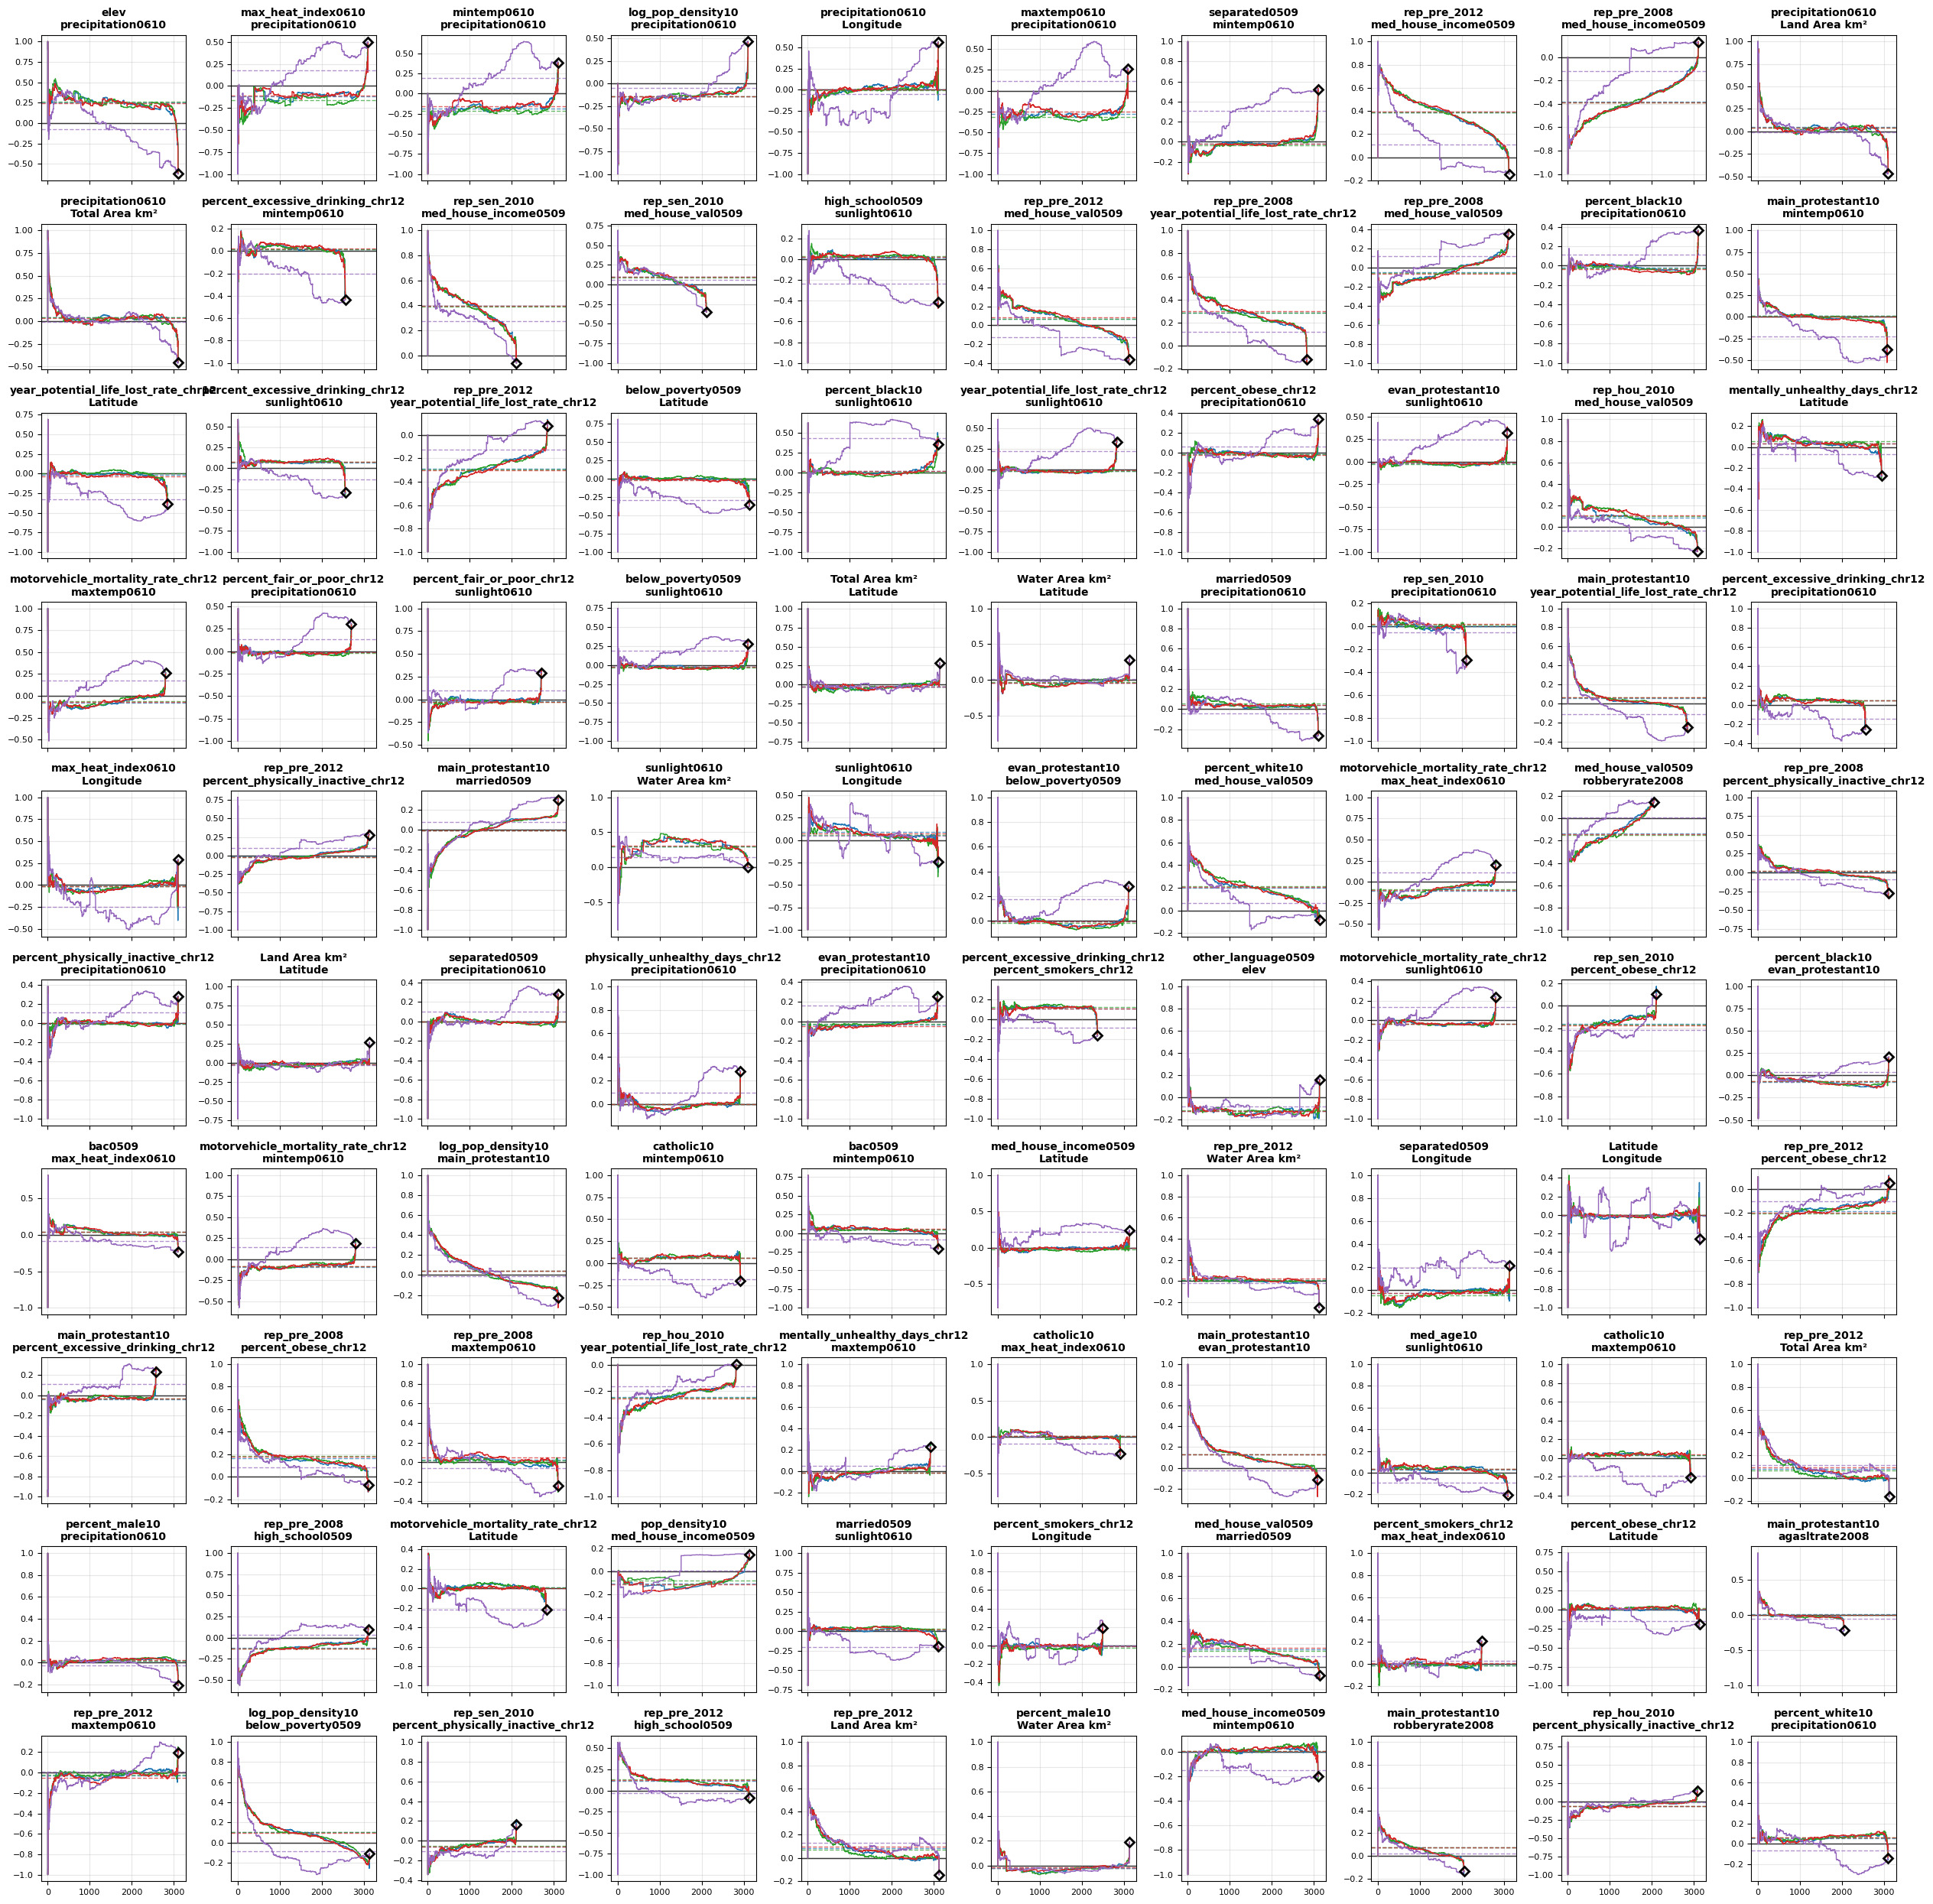

In [127]:
n_panels = 100
fig, axes = plot_timeseries_multiple1D(
    [
        trace_ALL_flat_flat[i] 
        for i 
        in ind_max_diff_trace_pearson_completeLinkage[-n_panels:][::-1]
    ], 
    [
        pairName_ALL_flat[i]
        for i 
        in ind_max_diff_trace_pearson_completeLinkage[-n_panels:][::-1]
    ]
)

In [128]:
fig.savefig(os.path.join(os.getcwd(), 'plot-spatial-corr_4-linkages_topDiffsOfAbsSigned_100_ALLpairs.png'), dpi=150, bbox_inches='tight')

### plotting functions used:
- plot_values
- plot_timeseries_multiple1D
- plot_multipanel_timeseries

### other non-plotting functions used:
- arg_sort_diff_trace_pearson (sorts data traces based on their difference between the final value and their mean) -- to see which traces are the most counter-intuitive
- arg_sort_diff_trace_pearson_jagged (version for working with jagged array of unequal lengths)
- compute_space_corr_matrix_wrapper (just a stupid wrapper, totally unnecesary) 